In [1]:
import os
import contextily as ctx
from asp_plot import bundle_adjust_plots as ba_plt
from asp_plot import io as asp_io

In [2]:
outdir = "~/Dropbox/UW_Shean/WV/2022/WV02_20220413_10300100D04DB500_10300100D0668800/"

ba_prefix = 'ba/ba_100ips_dg'
# ba_prefix = 'csm_refinement_all_pairs/csm_out'

map_crs = 'EPSG:32604'
refdem = 'COP30_lzw-adj_proj.tif' # NOT needed, because geodiff output is: *-initial_residuals_pointmap-diff.csv, but useful for titling map
refdem_abbrv = refdem[0:5]

# Use to compare multi-stage bundle_adjust results
# compares the initial bundle_adjust output with post-pc_align bundle_adjust output
# should actually ALWAYS run this after the first step (if `pc_align` version exists)
two_stage = False

In [3]:
resid_init, resid_final = asp_io.get_residual_gdfs(outdir, ba_prefix, two_stage=two_stage)

In [4]:
ctx_kwargs = {
    "crs": map_crs,
    "source": ctx.providers.Esri.WorldImagery,
    "attribution_size": 0,
    "alpha": 0.5,
}

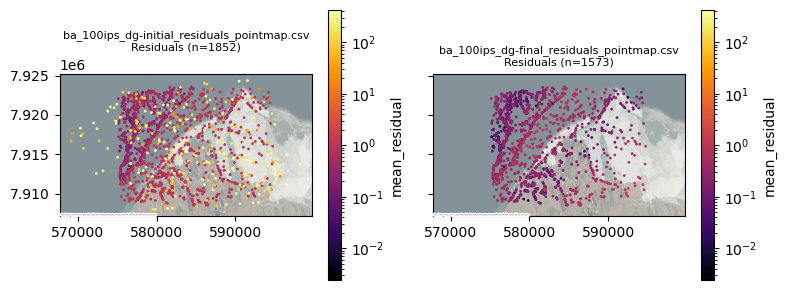

In [5]:
ba_plt.resid_plot(
    [resid_init, resid_final],
    col="mean_residual",
    lognorm=True,
    map_crs=map_crs,
    title_size=8,
    **ctx_kwargs
)

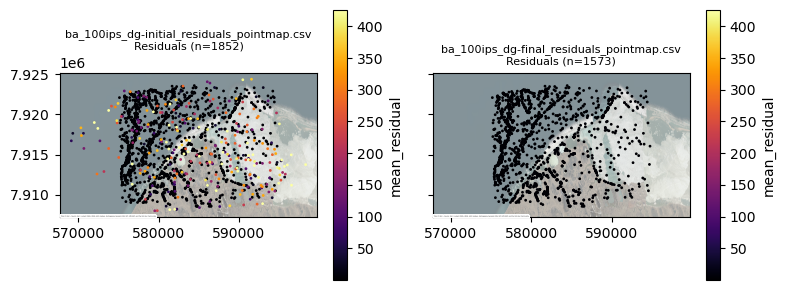

In [6]:
ba_plt.resid_plot(
    [resid_init, resid_final],
    col="mean_residual",
    lognorm=False,
    map_crs=map_crs,
    title_size=8,
    **ctx_kwargs
)

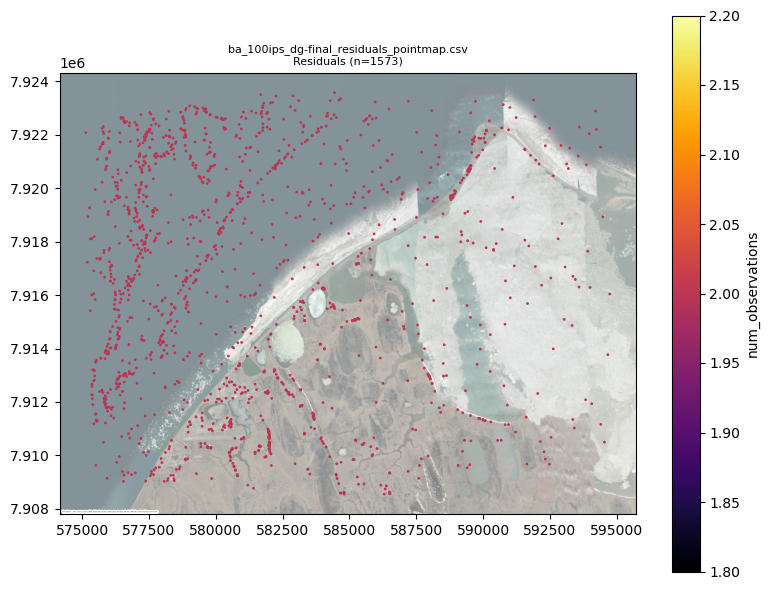

In [7]:
ba_plt.resid_plot(
    [resid_final],
    col="num_observations",
    lognorm=False,
    map_crs=map_crs,
    title_size=8,
    **ctx_kwargs
)